In [1]:
#%%
# Standard library imports
from argparse import ArgumentParser
import os, sys
THIS_DIR = os.path.abspath('')
PARENT_DIR = os.path.dirname(os.path.abspath(''))
sys.path.append(PARENT_DIR)

# Third party imports
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint
from torchdiffeq import odeint
from torchvision import utils
import matplotlib.pyplot as plt
import numpy as np

# local application imports
from lag_caVAE.lag import Lag_Net
from lag_caVAE.nn_models import MLP_Encoder, MLP, MLP_Decoder, PSD
from hyperspherical_vae.distributions import VonMisesFisher
from hyperspherical_vae.distributions import HypersphericalUniform
from utils import arrange_data, from_pickle, my_collate, ImageDataset
from examples.pend_lag_cavae_trainer import Model

seed_everything(0)
%matplotlib inline
DPI = 600

Global seed set to 0
Global seed set to 0


## Load Model

In [2]:
checkpoint_path = os.path.join(PARENT_DIR, 
                               'results', 
                               'pend',
                               'pend-lag-cavae-T_p=4-epoch=653-step=26159.ckpt')
model = Model.load_from_checkpoint(checkpoint_path)

In [3]:
ckpt = torch.load(checkpoint_path, map_location="cpu")
ckpt.keys()

dict_keys(['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'callbacks', 'optimizer_states', 'lr_schedulers', 'hparams_name', 'hyper_parameters'])

In [4]:
print(ckpt['callbacks'])

{"ModelCheckpoint{'monitor': 'monitor', 'mode': 'min', 'every_n_train_steps': 0, 'every_n_epochs': 1, 'train_time_interval': None, 'save_on_train_epoch_end': True}": {'monitor': 'monitor', 'best_model_score': tensor(14.2692), 'best_model_path': '/var/lib/condor/execute/slot1/dir_3350021/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=653-step=26159.ckpt', 'current_score': tensor(14.2692), 'dirpath': '/var/lib/condor/execute/slot1/dir_3350021/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints', 'best_k_models': {'/var/lib/condor/execute/slot1/dir_3350021/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=653-step=26159.ckpt': tensor(14.2692)}, 'kth_best_model_path': '/var/lib/condor/execute/slot1/dir_3350021/scratch/Lagrangian_caVAE-main/logs/pend-lag-cavae/lightning_logs/version_0/checkpoints/pend-lag-cavae-T_p=4-epoch=653-

## Prepare data

In [5]:
data_path=os.path.join(PARENT_DIR, 'datasets', 'pendulum-gym-image-dataset-test.pkl')
print(data_path)
test_dataset = ImageDataset(data_path, 19, ctrl=False)

test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False, collate_fn=my_collate)

/Lagrangian_caVAE-main/datasets/pendulum-gym-image-dataset-test.pkl


In [6]:
test_batch = next(iter(test_dataloader))
X, u = test_batch

In [7]:
# model.t_eval = torch.from_numpy(test_dataset.t_eval)
def extend_t_eval(t_eval, N_new):
    t_eval = np.asarray(t_eval)
    dt = t_eval[1] - t_eval[0]
    t0 = t_eval[0]
    return t0 + dt * np.arange(N_new)
t_eval = torch.from_numpy(test_dataset.t_eval)
extended = torch.tensor(extend_t_eval(t_eval, 60))
model.t_eval = extended
model.hparams.solver = 'rk4'
model(X, u)

/usr/local/lib/python3.8/site-packages/torch/distributions/distribution.py:53: UserWarning: <class 'hyperspherical_vae.distributions.hyperspherical_uniform.HypersphericalUniform'> does not define `arg_constraints`. Please set `arg_constraints = {}` or initialize the distribution with `validate_args=False` to turn off validation.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4358: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


torch.Size([20, 256, 32, 32])


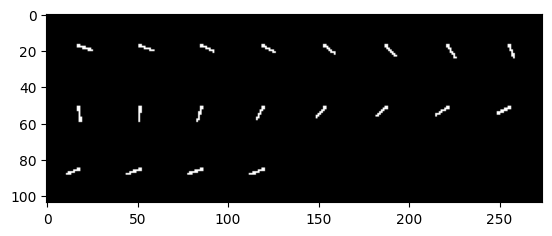

In [8]:
# data trajectory
b_ind = 0
print(X.shape)
grid = utils.make_grid(X[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([60, 256, 32, 32])


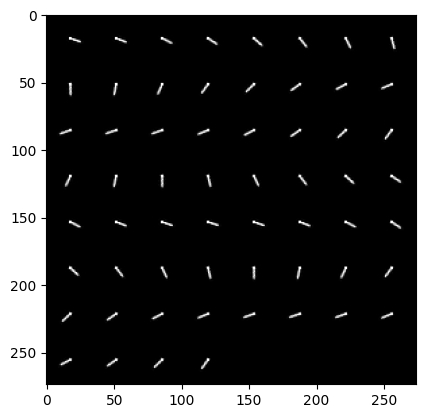

In [9]:
# prediction trajectory
print(model.Xrec.shape)
grid = utils.make_grid(model.Xrec[:, b_ind].view(-1, 1, 32, 32))
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

## Plot learned potential energy

In [10]:
q = np.linspace(0, 2*np.pi, 41)
cos_q = np.cos(q[:-1])
sin_q = np.sin(q[:-1])
cos_q_sin_q = np.stack((cos_q, sin_q), axis=1)
cos_q_sin_q = torch.tensor(cos_q_sin_q, dtype=torch.float32)

Text(0, 0.5, '$V(\\phi)$')

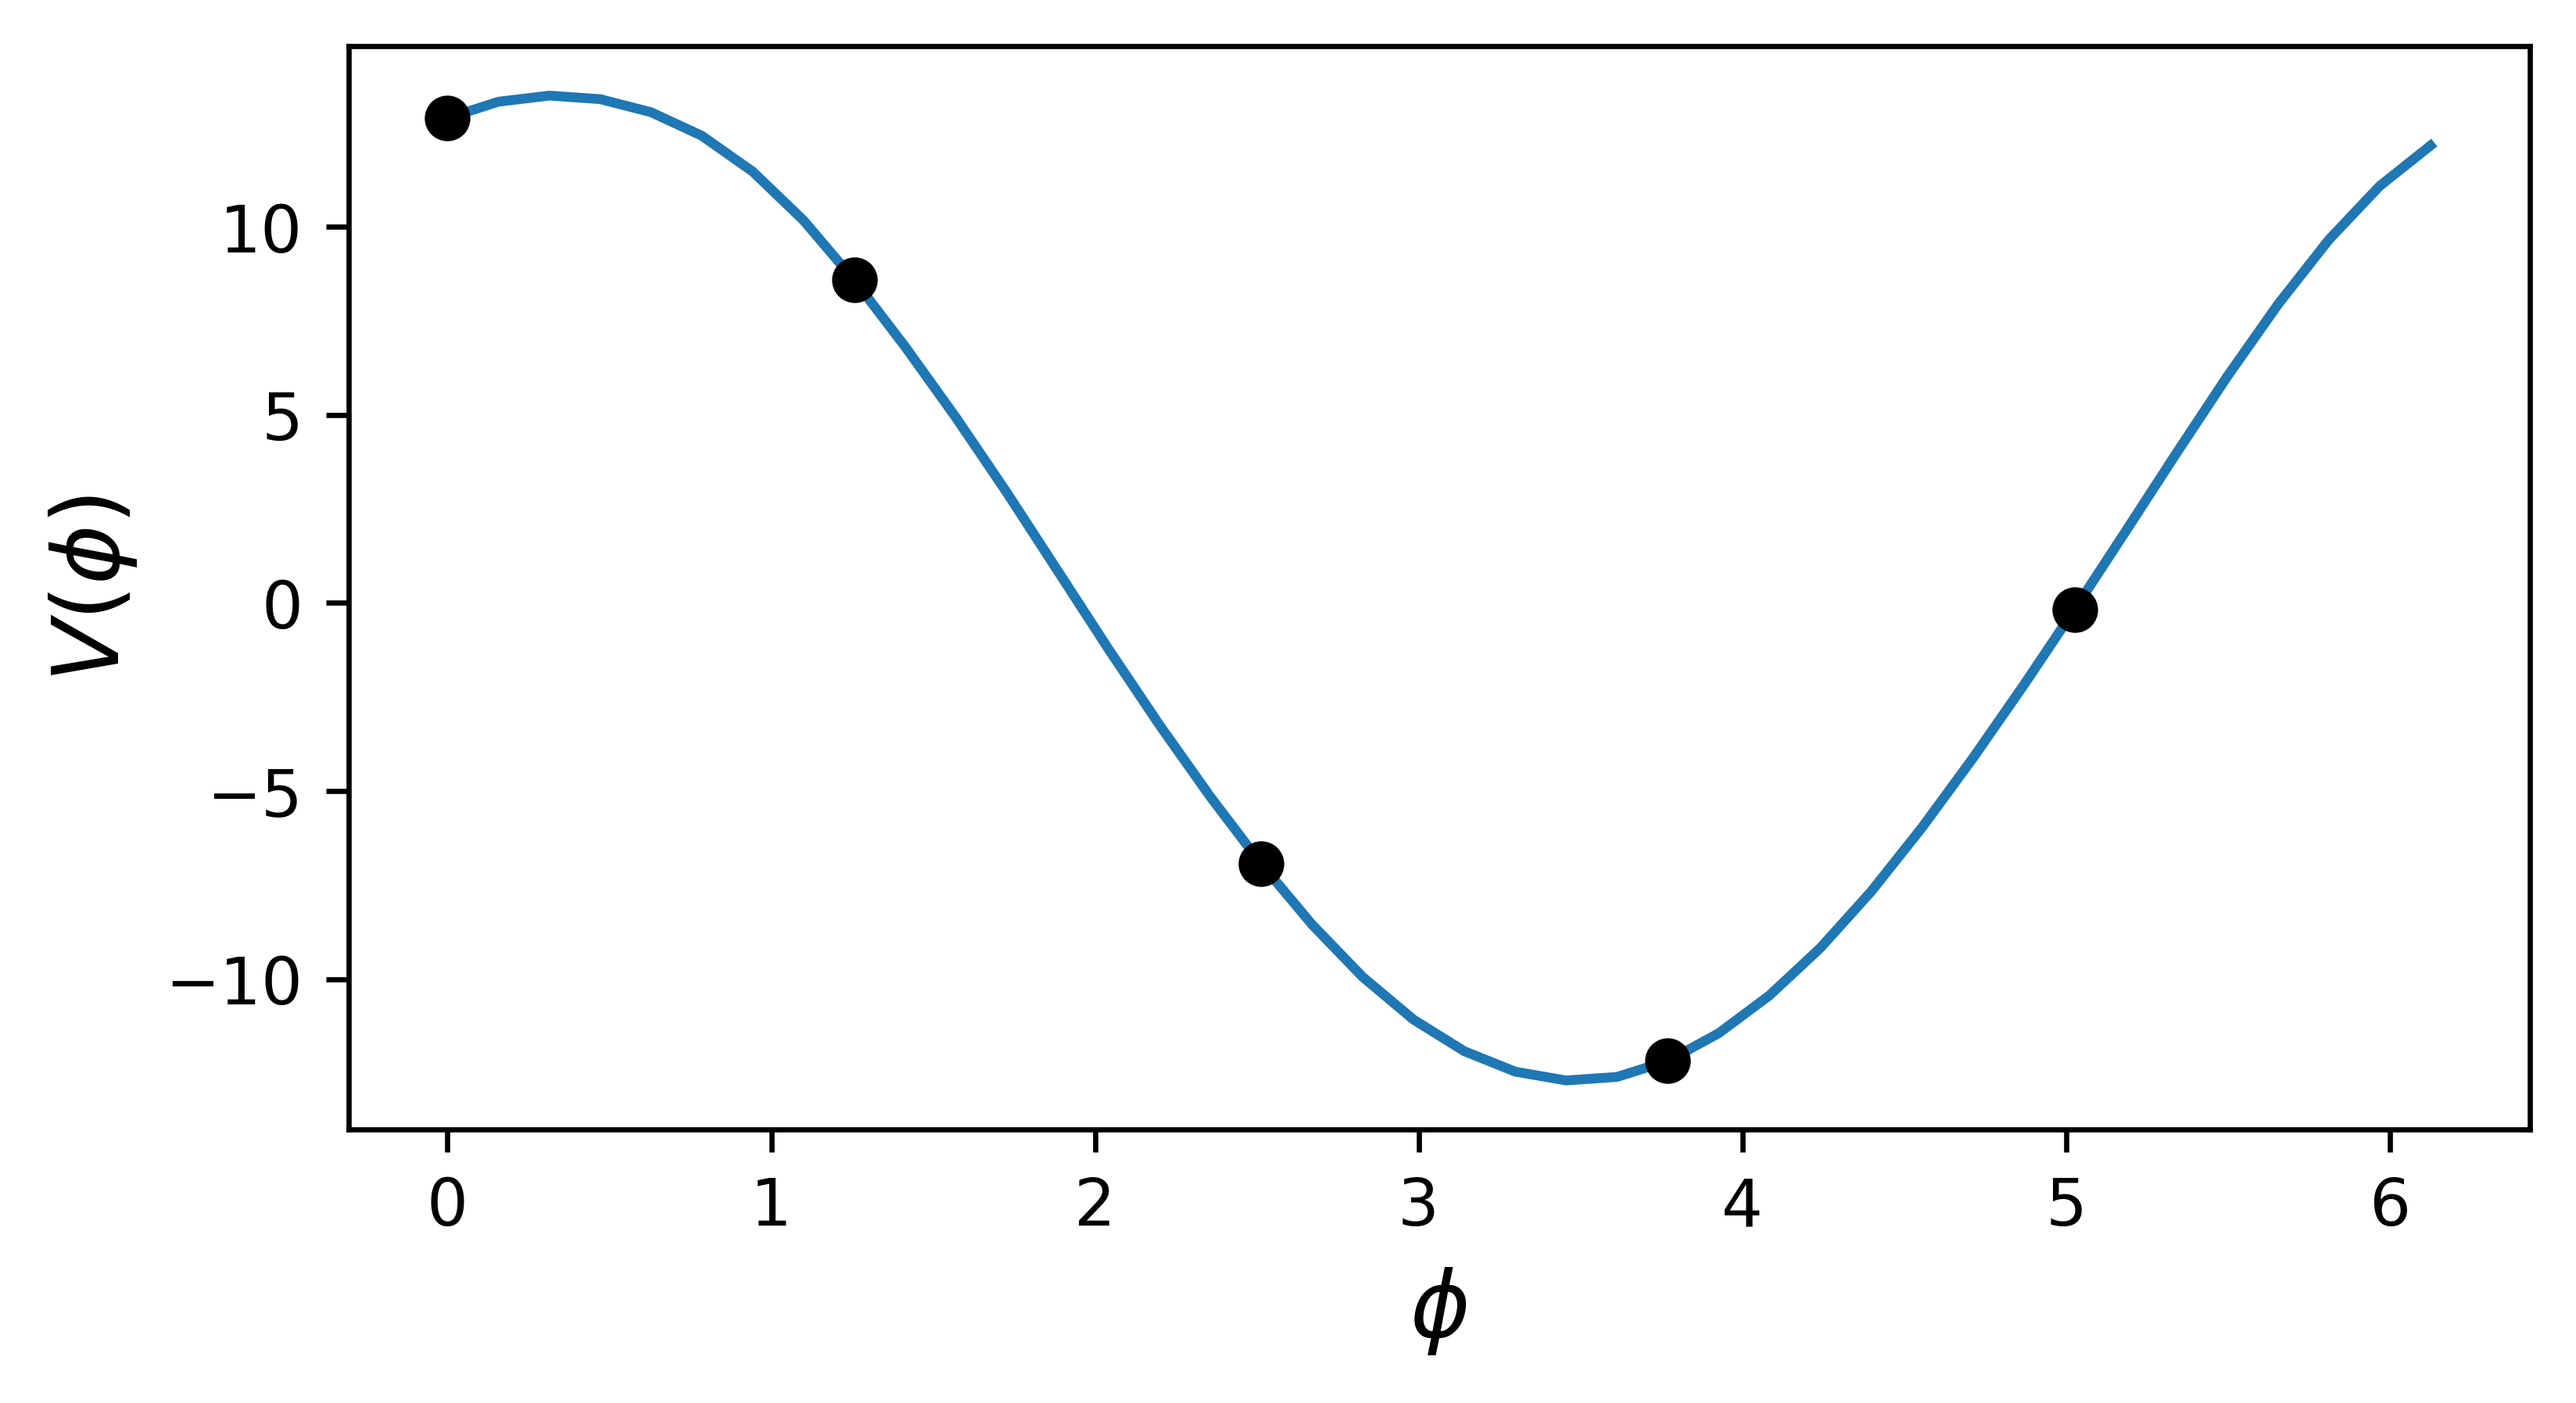

In [11]:
V_q = model.ode.V_net(cos_q_sin_q).detach().cpu().numpy()
fig = plt.figure(figsize=[6, 3], dpi=DPI)
markers_on = [0, 8, 16, 24, 32]
plt.plot(q[:-1], V_q, marker = 'o', markevery=markers_on, markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
plt.xlabel(r"$\phi$", fontsize=14)
plt.ylabel(r"$V(\phi)$", fontsize=14)
# plt.tight_layout()
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend_potential_energy'), bbox_inches='tight')

## Plot 5 reconstruction images corresponding to the black dots

/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4358: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.8/site-packages/torch/nn/functional.py:4296: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([60, 256, 32, 32])
torch.Size([40, 1, 32, 32])


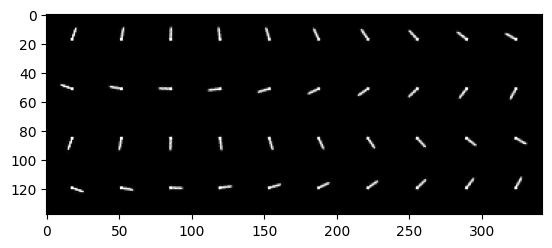

In [12]:
ones = torch.ones_like(cos_q_sin_q[:, 0:1])
content = model.obs_net(ones)

theta = model.get_theta_inv(cos_q_sin_q[:, 0], cos_q_sin_q[:, 1], 0, 0, bs=cos_q_sin_q.shape[0])
grid = F.affine_grid(theta, torch.Size((40, 1, 32, 32)))
Xrec = F.grid_sample(content.view(40, 1, 32, 32), grid)
print(model.Xrec.shape)
print(Xrec.shape)
fig = plt.figure()
grid = utils.make_grid(Xrec.view(40, 1, 32, 32), nrow=10)
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


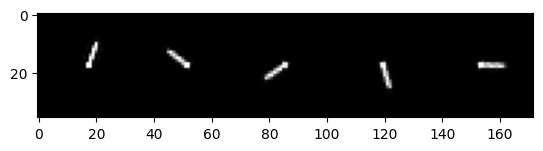

In [13]:
# for i in [0, 8, 16, 24, 32]:
#     fig = plt.figure()
#     plt.imshow(Xrec[i][0].detach().cpu().numpy(), cmap='gray')
#     plt.axis('off')
#     fig.savefig(os.path.join(PARENT_DIR, 'figures', f'pend_recon_{i}.png'), bbox_inches='tight')
grid = utils.make_grid(Xrec[0:40:8])
plt.imshow(grid.permute(1,2,0).detach().cpu().numpy())

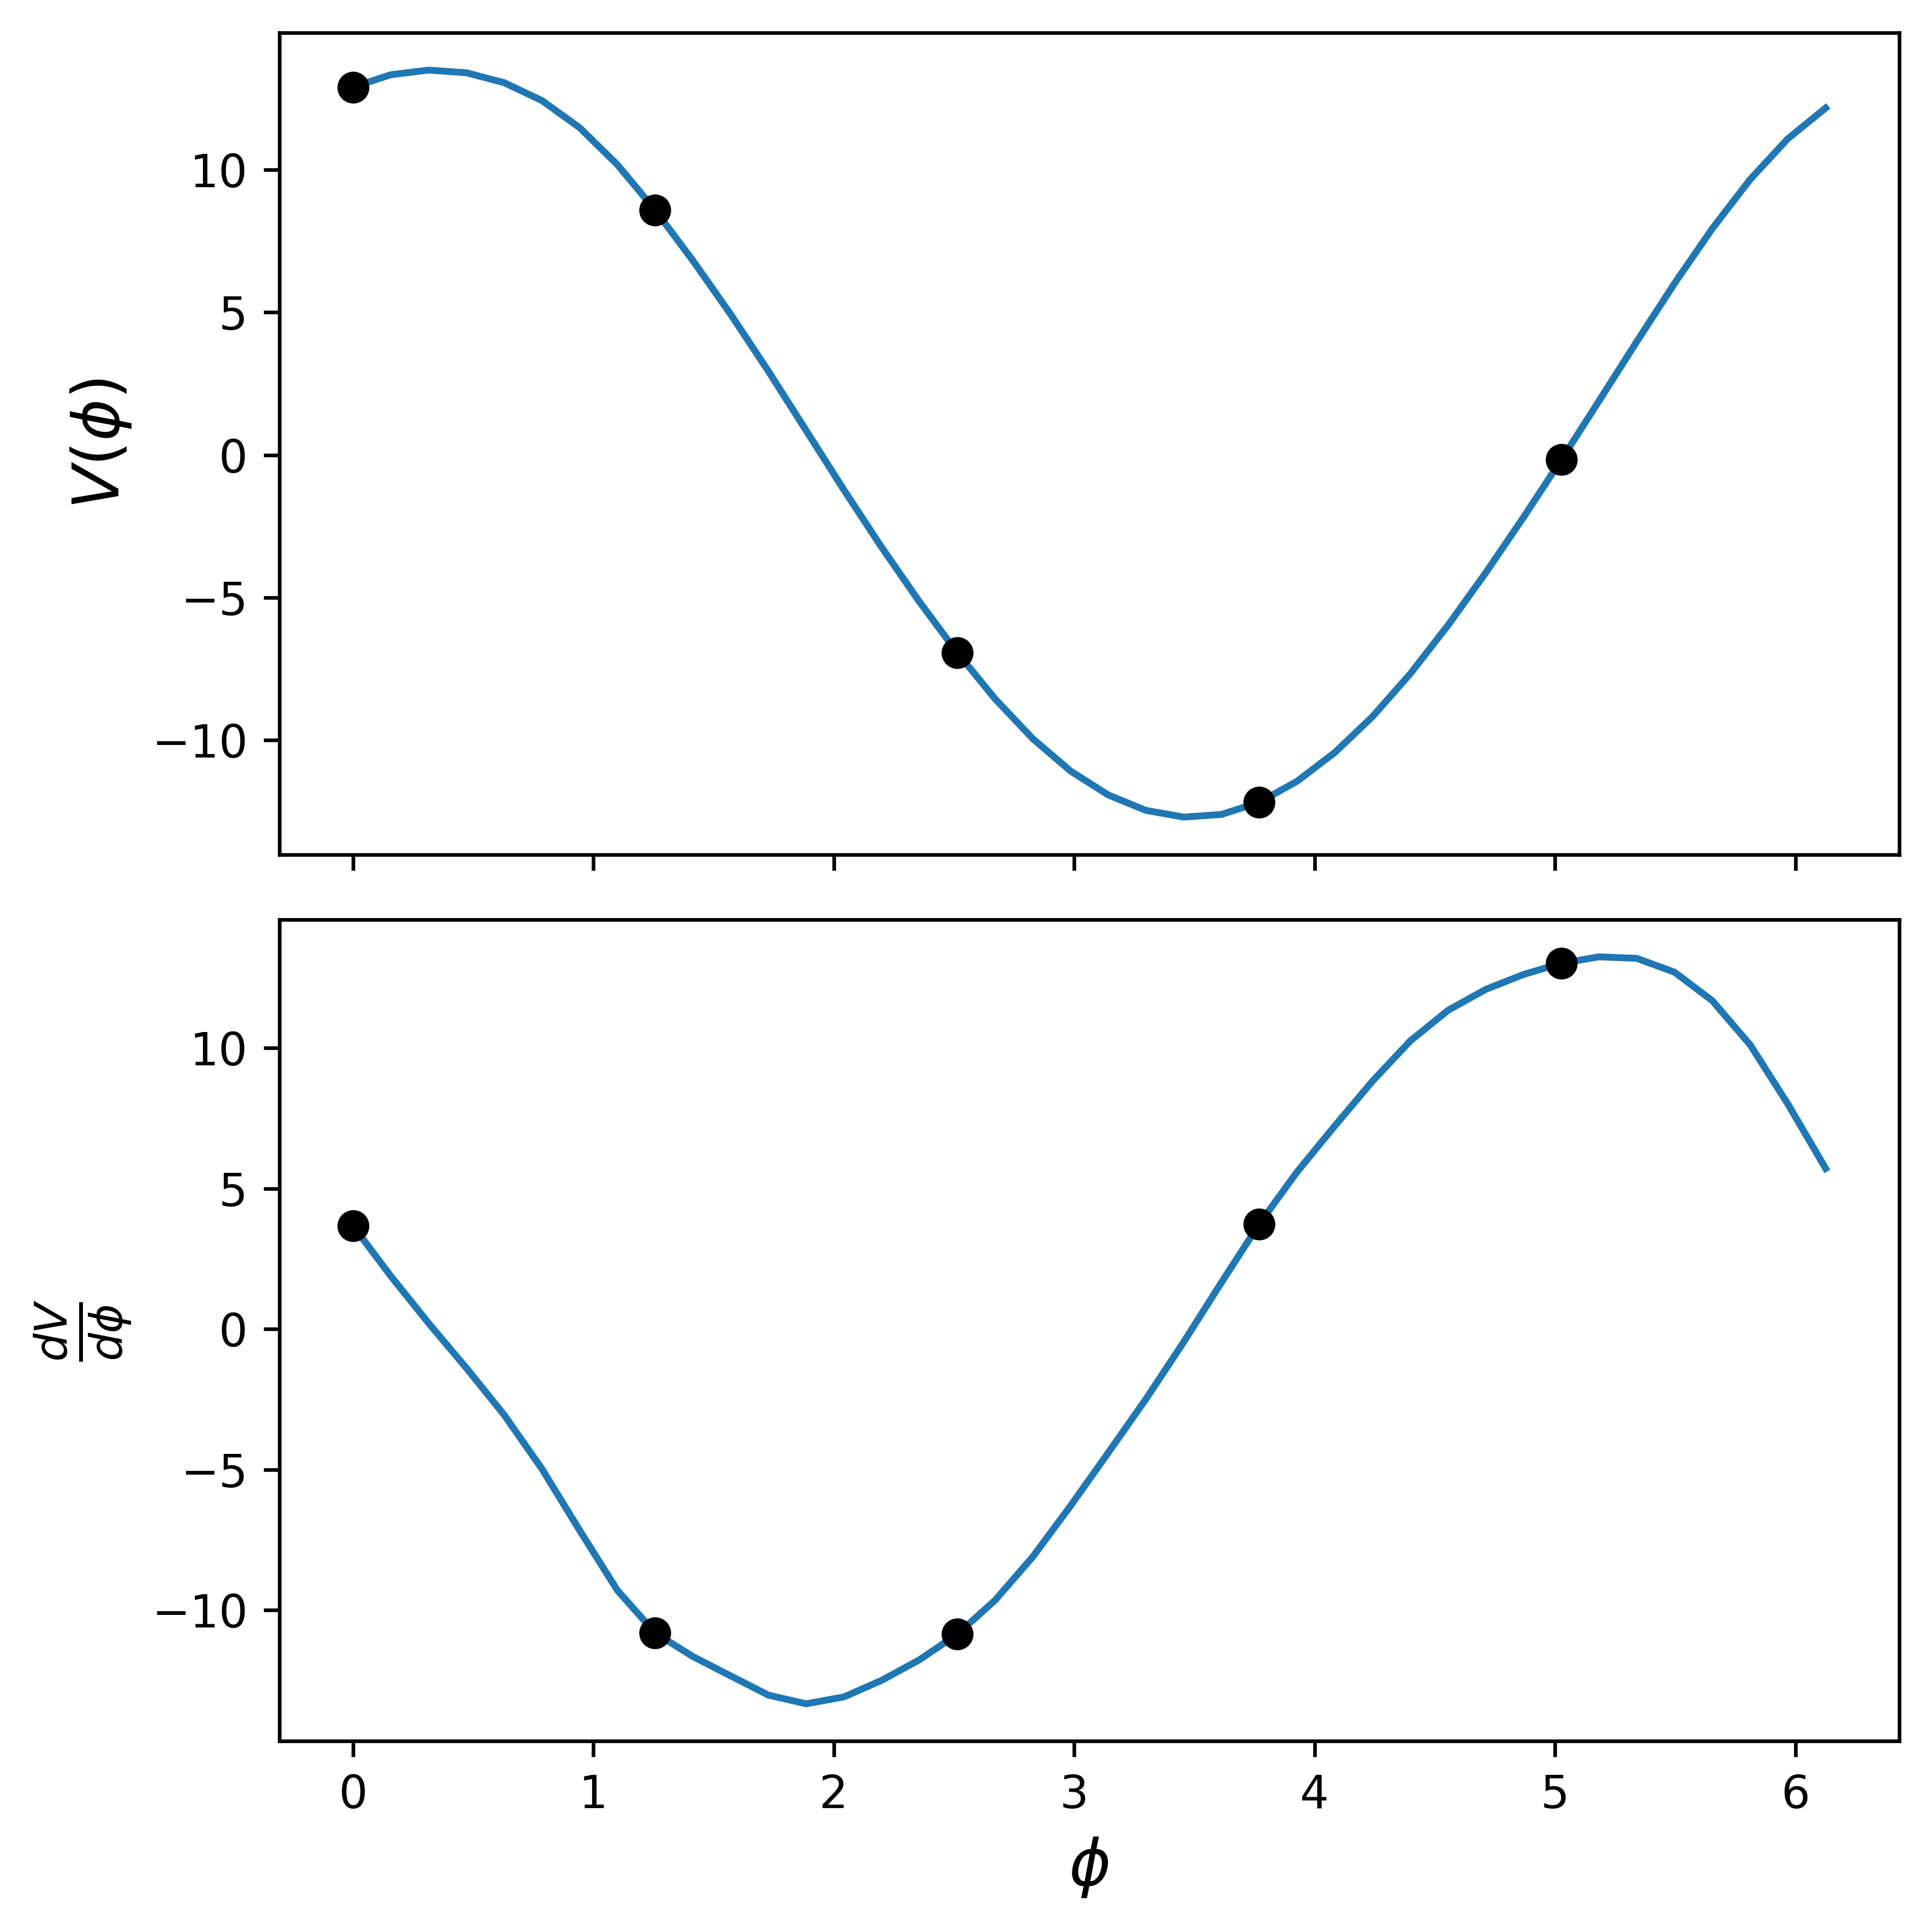

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data & Calculate Gradient (Autograd)
q = np.linspace(0, 2*np.pi, 41)

# We must create a tensor for 'q' first to track the gradient through sin/cos
q_tensor = torch.tensor(q[:-1], dtype=torch.float32, requires_grad=True)

# Recreate the stack using Torch so the computational graph is connected
cos_q_t = torch.cos(q_tensor)
sin_q_t = torch.sin(q_tensor)
cos_q_sin_q_tensor = torch.stack((cos_q_t, sin_q_t), dim=1)

# Forward pass
V_pred = model.ode.V_net(cos_q_sin_q_tensor)

# Backward pass to get dV/dq
dV_dq_tensor = torch.autograd.grad(
    outputs=V_pred,
    inputs=q_tensor,
    grad_outputs=torch.ones_like(V_pred),
    create_graph=False
)[0]

# Convert to Numpy for plotting
V_q = V_pred.detach().cpu().numpy()
dV_dq = dV_dq_tensor.detach().cpu().numpy()
markers_on = [0, 8, 16, 24, 32]

# 2. Plotting
# We double the height (3 -> 6) to stack two identical-looking plots
fig, ax = plt.subplots(2, 1, figsize=[6, 6], dpi=DPI, sharex=True)

# --- Top Plot: V(phi) (Exact copy of your styling) ---
ax[0].plot(q[:-1], V_q, marker='o', markevery=markers_on, 
           markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
ax[0].set_ylabel(r"$V(\phi)$", fontsize=14)

# --- Bottom Plot: dV/dphi (Exact copy of your styling) ---
ax[1].plot(q[:-1], dV_dq, marker='o', markevery=markers_on, 
           markerfacecolor=(0,0,0,1), markeredgecolor=(0,0,0,1))
ax[1].set_ylabel(r"$\frac{dV}{d\phi}$", fontsize=14)
ax[1].set_xlabel(r"$\phi$", fontsize=14)

# Align labels and save
fig.align_ylabels()
plt.tight_layout()
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend_potential_and_derivative'), bbox_inches='tight')
plt.show()

# Control

In [15]:
import gym, myenv
import numpy as np
from skimage import color
from gym import wrappers
env = gym.make('MyPendulum-v0')

# prepare model instance
model.hparams.solver = 'rk4'
model.bs = 1
model.d = 32

# get a goal image
q_star = 0.0
env.reset()
env.state = np.array([q_star, 0.0], dtype=np.float32)
goal_frame = env.render(mode='rgb_array')
goal_frame = color.rgb2gray(goal_frame)
goal_frame = torch.tensor(goal_frame, dtype=torch.float32)
env.close()

# given a goal image, design controller
# first encode the goal image to goal coordinates
_, _, goal_q_n = model.encode(goal_frame.view(1, 32*32))

/usr/local/lib/python3.8/site-packages/gym/logger.py:30: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize('%s: %s'%('WARN', msg % args), 'yellow'))


ImportError: 
    Error occurred while running `from pyglet.gl import *`
    HINT: make sure you have OpenGL install. On Ubuntu, you can run 'apt-get install python-opengl'.
    If you're running on a server, you may need a virtual frame buffer; something like this should work:
    'xvfb-run -s "-screen 0 1400x900x24" python <your_script.py>'
    

In [ ]:
goal_q_n

In [ ]:
q0 = 3.14

env.reset()
env.state = np.array([q0, 0.0], dtype=np.float32)
frame = color.rgb2gray(env.render(mode='rgb_array'))
frames = [frame]

frame = torch.tensor(frame, dtype=torch.float32)

for i in range(100):
    _, _, q_n = model.encode(frame.view(1, 32*32))
    
    if i==0:
        prev_q_n = q_n
        
    q_dot = model.angle_vel_est(prev_q_n, q_n, 0.05)

    V_q = model.ode.V_net(q_n)
    dV = torch.autograd.grad(V_q, q_n)[0]
    dV_dcos_q, dV_dsin_q = dV.split([1, 1], dim=1)
    dV_dq = - dV_dcos_q * q_n[:, 1] + dV_dsin_q * q_n[:, 0]
    g_q = model.ode.g_net(q_n)

#     energy_shaping = torch.zeros(2, 1, dtype=torch.float32)
#     energy_shaping[0][0] = dV_dr[0][0] - 3* (r_cos_phi_sin_phi[0][0] - 0.0)
#     energy_shaping[1][0] = 2 * dV_dphi[0][0]

    energy_shaping = dV_dq - 6 * (q_n[0, 1] * goal_q_n[0, 0] - q_n[0, 0] * goal_q_n[0, 1])
    damping_injection = - 1 * q_dot.T

    u = 1/g_q * (energy_shaping + damping_injection)

    u = u.detach().cpu().numpy()
    env.step(u)

    frame = color.rgb2gray(env.render(mode='rgb_array'))
    frames.append(frame)
    frame = torch.tensor(frame, dtype=torch.float32)

    prev_q_n = q_n

env.close()

In [ ]:
fig = plt.figure(figsize=(16, 4), dpi=DPI)
for i in range(13):
    plt.subplot(1, 13, i+1)
    plt.imshow(frames[i*8], cmap='gray')
    plt.axis('off')
    
# fig.savefig(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.png'), bbox_inches='tight')

In [ ]:
# import imageio
# imageio.mimsave(os.path.join(PARENT_DIR, 'figures', 'pend-ctrl.gif'), frames, duration=0.05)

control animation ![control sequence](../figures/pend-ctrl.gif)

In [16]:
model.hparams

"T_pred":                            4
"accelerator":                       None
"accumulate_grad_batches":           None
"amp_backend":                       native
"amp_level":                         None
"annealing":                         False
"auto_lr_find":                      False
"auto_scale_batch_size":             False
"auto_select_gpus":                  False
"batch_size":                        512
"benchmark":                         False
"check_val_every_n_epoch":           1
"checkpoint_callback":               None
"default_root_dir":                  None
"detect_anomaly":                    False
"deterministic":                     False
"devices":                           None
"enable_checkpointing":              True
"enable_model_summary":              True
"enable_progress_bar":               True
"fast_dev_run":                      False
"flush_logs_every_n_steps":          None
"gpus":                              1
"gradient_clip_algorithm":        